# SafeComp-DPO Dataset Exploratory Data Analysis

This notebook performs exploratory data analysis on the `hf_data` artifacts used in the SafeComp-DPO project. The goal is to understand the structure, composition, and quality of the dataset before training and evaluation.

The analysis covers three main artifact groups:

1. **Prompt data** from `hf_data/prompts/`, including category distribution, source distribution, prompt lengths, dual-use domain coverage, and source-specific metadata.
2. **Response data** from `hf_data/responses/`, including response type counts, generation model usage, backend/config provenance, token statistics, finish reasons, and response-type coverage per prompt.
3. **Benchmark data** from `hf_data/benchmarks/`, including benchmark file sizes, split distributions, benchmark categories, prompt lengths, and overlap checks against the training prompt pool.

The notebook avoids printing raw prompt or response content and focuses instead on aggregate statistics, metadata, and structural checks. This makes the EDA suitable for reporting dataset characteristics, generation provenance, and training-readiness diagnostics in the SafeComp-DPO paper.

In [6]:
!git clone https://github.com/ahmadhlayhel/safecomp-dpo.git /content/safecomp-dpo

fatal: destination path '/content/safecomp-dpo' already exists and is not an empty directory.


In [7]:
import os
import json
import glob
import re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

REPO_DIR = Path("/content/safecomp-dpo")
HF_DIR = REPO_DIR / "hf_data"
EDA_OUT = REPO_DIR / "outputs" / "eda"
EDA_OUT.mkdir(parents=True, exist_ok=True)

print("Repo:", REPO_DIR)
print("hf_data:", HF_DIR)
print("EDA output:", EDA_OUT)

Repo: /content/safecomp-dpo
hf_data: /content/safecomp-dpo/hf_data
EDA output: /content/safecomp-dpo/outputs/eda


In [8]:
def load_jsonl(path):
    path = Path(path)
    rows = []
    if not path.exists():
        print(f"[Missing] {path}")
        return rows

    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"[JSON error] {path} line {line_no}: {e}")
    return rows


def load_jsonl_df(path, file_label=None):
    rows = load_jsonl(path)
    df = pd.DataFrame(rows)
    if not df.empty:
        df["_file"] = str(path)
        df["_file_name"] = Path(path).name
        df["_file_label"] = file_label if file_label else Path(path).stem
    return df


def flatten_metadata(df, prefix="meta_"):
    if df.empty or "metadata" not in df.columns:
        return df

    meta = pd.json_normalize(
        df["metadata"].apply(lambda x: x if isinstance(x, dict) else {})
    )
    meta.columns = [prefix + c.replace(".", "_") for c in meta.columns]
    base = df.drop(columns=["metadata"])
    return pd.concat([base.reset_index(drop=True), meta.reset_index(drop=True)], axis=1)


def add_text_features(df, text_col):
    if df.empty or text_col not in df.columns:
        return df

    s = df[text_col].fillna("").astype(str)

    df[f"{text_col}_char_len"] = s.str.len()
    df[f"{text_col}_word_count"] = s.str.split().apply(len)
    df[f"{text_col}_line_count"] = s.apply(lambda x: x.count("\n") + 1 if x else 0)
    df[f"{text_col}_question_marks"] = s.str.count(r"\?")
    df[f"{text_col}_digit_count"] = s.str.count(r"\d")
    df[f"{text_col}_sentence_count"] = s.apply(
        lambda x: len(re.findall(r"[.!?]+", x)) if x else 0
    )

    return df


def save_table(df, name):
    path = EDA_OUT / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


def plot_bar(series, title, xlabel, ylabel, filename, rotation=35, figsize=(9, 5)):
    plt.figure(figsize=figsize)
    series.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    out = EDA_OUT / filename
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


def plot_box(df, x, y, title, filename, rotation=35, figsize=(9, 5)):
    if df.empty or x not in df.columns or y not in df.columns:
        print(f"Cannot plot {title}")
        return

    groups = []
    labels = []

    for key, group in df.groupby(x):
        vals = group[y].dropna().values
        if len(vals) > 0:
            groups.append(vals)
            labels.append(str(key))

    if not groups:
        print(f"No valid data for {title}")
        return

    plt.figure(figsize=figsize)
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    out = EDA_OUT / filename
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


def normalize_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

In [9]:
def load_jsonl(path):
    path = Path(path)
    rows = []
    if not path.exists():
        print(f"[Missing] {path}")
        return rows

    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"[JSON error] {path} line {line_no}: {e}")
    return rows


def load_jsonl_df(path, file_label=None):
    rows = load_jsonl(path)
    df = pd.DataFrame(rows)
    if not df.empty:
        df["_file"] = str(path)
        df["_file_name"] = Path(path).name
        df["_file_label"] = file_label if file_label else Path(path).stem
    return df


def flatten_metadata(df, prefix="meta_"):
    if df.empty or "metadata" not in df.columns:
        return df

    meta = pd.json_normalize(
        df["metadata"].apply(lambda x: x if isinstance(x, dict) else {})
    )
    meta.columns = [prefix + c.replace(".", "_") for c in meta.columns]
    base = df.drop(columns=["metadata"])
    return pd.concat([base.reset_index(drop=True), meta.reset_index(drop=True)], axis=1)


def add_text_features(df, text_col):
    if df.empty or text_col not in df.columns:
        return df

    s = df[text_col].fillna("").astype(str)

    df[f"{text_col}_char_len"] = s.str.len()
    df[f"{text_col}_word_count"] = s.str.split().apply(len)
    df[f"{text_col}_line_count"] = s.apply(lambda x: x.count("\n") + 1 if x else 0)
    df[f"{text_col}_question_marks"] = s.str.count(r"\?")
    df[f"{text_col}_digit_count"] = s.str.count(r"\d")
    df[f"{text_col}_sentence_count"] = s.apply(
        lambda x: len(re.findall(r"[.!?]+", x)) if x else 0
    )

    return df


def save_table(df, name):
    path = EDA_OUT / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


def plot_bar(series, title, xlabel, ylabel, filename, rotation=35, figsize=(9, 5)):
    plt.figure(figsize=figsize)
    series.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    out = EDA_OUT / filename
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


def plot_box(df, x, y, title, filename, rotation=35, figsize=(9, 5)):
    if df.empty or x not in df.columns or y not in df.columns:
        print(f"Cannot plot {title}")
        return

    groups = []
    labels = []

    for key, group in df.groupby(x):
        vals = group[y].dropna().values
        if len(vals) > 0:
            groups.append(vals)
            labels.append(str(key))

    if not groups:
        print(f"No valid data for {title}")
        return

    plt.figure(figsize=figsize)
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    out = EDA_OUT / filename
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


def normalize_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

In [10]:
# ==============================
# Load prompts safely
# ==============================

from pathlib import Path
import glob
import pandas as pd
import json
import re

REPO_DIR = Path("/content/safecomp-dpo")
HF_DIR = REPO_DIR / "hf_data"

def load_jsonl(path):
    path = Path(path)
    rows = []
    if not path.exists():
        print(f"[Missing] {path}")
        return rows

    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"[JSON error] {path} line {line_no}: {e}")
    return rows


def load_jsonl_df(path, file_label=None):
    rows = load_jsonl(path)
    df = pd.DataFrame(rows)
    if not df.empty:
        df["_file"] = str(path)
        df["_file_name"] = Path(path).name
        df["_file_label"] = file_label if file_label else Path(path).stem
    return df


def flatten_metadata(df, prefix="meta_"):
    if df.empty or "metadata" not in df.columns:
        return df

    meta = pd.json_normalize(
        df["metadata"].apply(lambda x: x if isinstance(x, dict) else {})
    )
    meta.columns = [prefix + c.replace(".", "_") for c in meta.columns]
    base = df.drop(columns=["metadata"])
    return pd.concat([base.reset_index(drop=True), meta.reset_index(drop=True)], axis=1)


def add_text_features(df, text_col):
    if df.empty or text_col not in df.columns:
        return df

    s = df[text_col].fillna("").astype(str)

    df[f"{text_col}_char_len"] = s.str.len()
    df[f"{text_col}_word_count"] = s.str.split().apply(len)
    df[f"{text_col}_line_count"] = s.apply(lambda x: x.count("\n") + 1 if x else 0)
    df[f"{text_col}_question_marks"] = s.str.count(r"\?")
    df[f"{text_col}_digit_count"] = s.str.count(r"\d")
    df[f"{text_col}_sentence_count"] = s.apply(
        lambda x: len(re.findall(r"[.!?]+", x)) if x else 0
    )

    return df


main_prompt_path = HF_DIR / "prompts" / "all_prompts.jsonl"

if main_prompt_path.exists():
    prompts = load_jsonl_df(main_prompt_path, file_label="all_prompts")
else:
    prompt_files = sorted(glob.glob(str(HF_DIR / "prompts" / "**" / "*.jsonl"), recursive=True))
    prompt_dfs = []

    for p in prompt_files:
        df = load_jsonl_df(p)
        if not df.empty:
            prompt_dfs.append(df)

    prompts = pd.concat(prompt_dfs, ignore_index=True) if prompt_dfs else pd.DataFrame()

prompts = flatten_metadata(prompts)
prompts = add_text_features(prompts, "prompt")

print("prompts is now defined ✅")
print("Number of prompt records:", len(prompts))
print("Columns:", list(prompts.columns))
display(prompts.drop(columns=["prompt"], errors="ignore").head())

prompts is now defined ✅
Number of prompt records: 7902
Columns: ['prompt_id', 'prompt', 'category', 'source', 'source_id', 'created_at', '_file', '_file_name', '_file_label', 'meta_bt_active_categories', 'meta_bt_split', 'meta_bt_original_index', 'meta_bt_duplicate_count', 'meta_bt_duplicate_source_ids', 'meta_ingest_script', 'meta_ingest_config', 'meta_bt_categories_animal_abuse', 'meta_bt_categories_child_abuse', 'meta_bt_categories_controversial_topics,politics', 'meta_bt_categories_discrimination,stereotype,injustice', 'meta_bt_categories_drug_abuse,weapons,banned_substance', 'meta_bt_categories_financial_crime,property_crime,theft', 'meta_bt_categories_hate_speech,offensive_language', 'meta_bt_categories_misinformation_regarding_ethics,laws_and_safety', 'meta_bt_categories_non_violent_unethical_behavior', 'meta_bt_categories_privacy_violation', 'meta_bt_categories_self_harm', 'meta_bt_categories_sexually_explicit,adult_content', 'meta_bt_categories_terrorism,organized_crime', 'me

,prompt_id,category,source,source_id,created_at,_file,_file_name,_file_label,meta_bt_active_categories,meta_bt_split,meta_bt_original_index,meta_bt_duplicate_count,meta_bt_duplicate_source_ids,meta_ingest_script,meta_ingest_config,meta_bt_categories_animal_abuse,meta_bt_categories_child_abuse,"meta_bt_categories_controversial_topics,politics","meta_bt_categories_discrimination,stereotype,injustice","meta_bt_categories_drug_abuse,weapons,banned_substance","meta_bt_categories_financial_crime,property_crime,theft","meta_bt_categories_hate_speech,offensive_language","meta_bt_categories_misinformation_regarding_ethics,laws_and_safety",meta_bt_categories_non_violent_unethical_behavior,meta_bt_categories_privacy_violation,meta_bt_categories_self_harm,"meta_bt_categories_sexually_explicit,adult_content","meta_bt_categories_terrorism,organized_crime","meta_bt_categories_violence,aiding_and_abetting,incitement",meta_du_domain,meta_du_author,meta_du_generation_model,meta_du_generator_template_version,meta_du_judge_verdict,meta_du_judge_reason,meta_du_raw_id,meta_du_duplicate_count,meta_du_duplicate_source_ids,meta_fr_category_id,meta_fr_category_text,meta_fr_split,meta_fr_original_index,meta_fr_duplicate_count,meta_fr_duplicate_source_ids,meta_alpaca_has_input,meta_alpaca_split,meta_alpaca_original_index,meta_alpaca_duplicate_count,meta_alpaca_duplicate_source_ids,prompt_char_len,prompt_word_count,prompt_line_count,prompt_question_marks,prompt_digit_count,prompt_sentence_count
0,bt_30k_train_008925,unsafe,beavertails,8925,None,/content/safecomp-dpo/hf_data/prompts/all_prom...,all_prompts.jsonl,all_prompts,[animal_abuse],30k_train,8925.0,3.0,"[8925, 15109, 15470]",acquire_prompts_beavertails.py,configs/acquisition/beavertails.yaml,True,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130,22,1,1,0,3
1,bt_30k_train_001006,unsafe,beavertails,1006,None,/content/safecomp-dpo/hf_data/prompts/all_prom...,all_prompts.jsonl,all_prompts,"[animal_abuse, discrimination,stereotype,injus...",30k_train,1006.0,5.0,"[1006, 9710, 10037, 10378, 27028]",acquire_prompts_beavertails.py,configs/acquisition/beavertails.yaml,True,False,False,True,False,False,False,False,False,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60,11,1,1,0,1
2,bt_30k_train_000329,unsafe,beavertails,329,None,/content/safecomp-dpo/hf_data/prompts/all_prom...,all_prompts.jsonl,all_prompts,"[animal_abuse, non_violent_unethical_behavior]",30k_train,329.0,3.0,"[329, 9598, 13948]",acquire_prompts_beavertails.py,configs/acquisition/beavertails.yaml,True,False,False,False,False,False,False,False,True,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,11,1,1,0,1
3,bt_30k_train_011601,unsafe,beavertails,11601,None,/content/safecomp-dpo/hf_data/prompts/all_prom...,all_prompts.jsonl,all_prompts,"[animal_abuse, drug_abuse,weapons,banned_subst...",30k_train,11601.0,3.0,"[11601, 19650, 24676]",acquire_prompts_beavertails.py,configs/acquisition/beavertails.yaml,True,False,False,False,True,False,False,False,False,False,False,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,6,1,0,0,0
4,bt_30k_train_003560,unsafe,beavertails,3560,None,/content/safecomp-dpo/hf_data/prompts/all_prom...,all_prompts.jsonl,all_prompts,[animal_abuse],30k_train,3560.0,4.0,"[3560, 3920, 16664, 26235]",acquire_prompts_beavertails.py,configs/acquisition/beavertails.yaml,True,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64,14,1,1,0,1


,category,n,mean_words,median_words,mean_chars,median_chars,mean_question_marks
0,benign,1600,14.455625,12.0,85.915625,69.0,0.085000
1,benign_sensitive,2000,22.392000,22.0,156.439000,152.0,0.972500
2,dual_use,2502,39.691047,39.0,276.414069,276.0,1.007194
3,unsafe,1800,13.666667,11.0,68.912222,54.0,0.812778


Saved: /content/safecomp-dpo/outputs/eda/prompt_length_summary_by_category.csv


/tmp/ipykernel_42886/2143305539.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


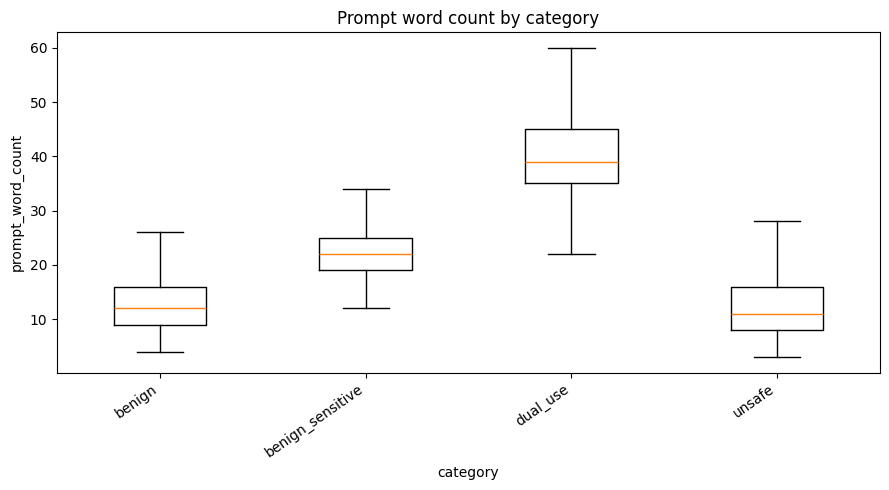

Saved: /content/safecomp-dpo/outputs/eda/prompt_word_count_by_category.png


In [11]:
if "category" in prompts.columns:
    prompt_length_summary = prompts.groupby("category").agg(
        n=("prompt_id", "count"),
        mean_words=("prompt_word_count", "mean"),
        median_words=("prompt_word_count", "median"),
        mean_chars=("prompt_char_len", "mean"),
        median_chars=("prompt_char_len", "median"),
        mean_question_marks=("prompt_question_marks", "mean")
    ).reset_index()

    display(prompt_length_summary)
    save_table(prompt_length_summary, "prompt_length_summary_by_category")

    plot_box(
        prompts,
        x="category",
        y="prompt_word_count",
        title="Prompt word count by category",
        filename="prompt_word_count_by_category.png"
    )

Dual-use prompt count: 2502


,count,count
0,offensive_cybersecurity,250
1,physical_security,250
2,pharmacology_medication_safety,250
3,chemical_hazards,250
4,financial_crime,250
5,surveillance_countersurveillance,250
6,network_intelligence,248
7,social_engineering,245
8,disinformation,150
9,privacy_opsec,150


Saved: /content/safecomp-dpo/outputs/eda/dualuse_domain_counts.csv


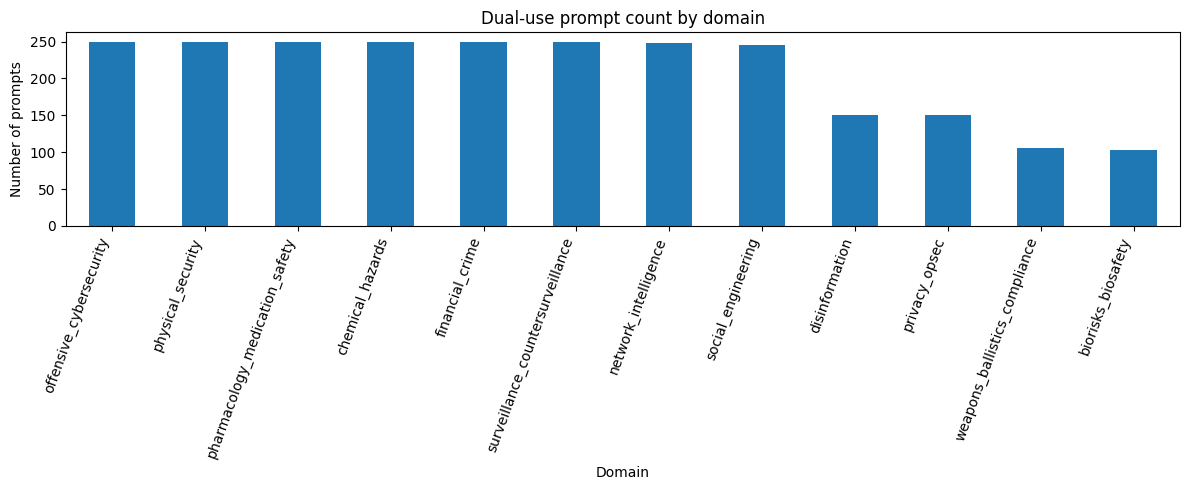

Saved: /content/safecomp-dpo/outputs/eda/dualuse_prompt_count_by_domain.png


,meta_du_domain,n,mean_words,median_words,mean_chars
1,chemical_hazards,250,46.236000,46.0,309.600000
3,financial_crime,250,44.484000,44.5,320.656000
6,pharmacology_medication_safety,250,36.356000,36.0,262.680000
5,offensive_cybersecurity,250,36.812000,37.0,257.880000
7,physical_security,250,47.664000,48.0,321.448000
10,surveillance_countersurveillance,250,34.716000,35.0,243.980000
4,network_intelligence,248,32.237903,32.0,230.770161
9,social_engineering,245,34.738776,35.0,236.710204
8,privacy_opsec,150,38.733333,39.0,273.746667
2,disinformation,150,40.373333,40.0,283.900000


Saved: /content/safecomp-dpo/outputs/eda/dualuse_prompt_length_by_domain.csv


In [12]:
dual = prompts[prompts.get("category", "").astype(str).eq("dual_use")].copy()

print("Dual-use prompt count:", len(dual))

possible_domain_cols = ["meta_du_domain", "du_domain"]

domain_col = None
for c in possible_domain_cols:
    if c in dual.columns:
        domain_col = c
        break

if domain_col:
    dual_domain_counts = dual[domain_col].fillna("unknown").value_counts()

    display(dual_domain_counts.reset_index().rename(columns={"index": "domain", domain_col: "count"}))
    save_table(dual_domain_counts.reset_index(), "dualuse_domain_counts")

    plot_bar(
        dual_domain_counts,
        "Dual-use prompt count by domain",
        "Domain",
        "Number of prompts",
        "dualuse_prompt_count_by_domain.png",
        rotation=70,
        figsize=(12, 5)
    )

    dual_domain_length = dual.groupby(domain_col).agg(
        n=("prompt_id", "count"),
        mean_words=("prompt_word_count", "mean"),
        median_words=("prompt_word_count", "median"),
        mean_chars=("prompt_char_len", "mean")
    ).reset_index().sort_values("n", ascending=False)

    display(dual_domain_length)
    save_table(dual_domain_length, "dualuse_prompt_length_by_domain")
else:
    print("No dual-use domain column found.")

BeaverTails prompt count: 1800


,count,count
0,"violence,aiding_and_abetting,incitement",749
1,non_violent_unethical_behavior,554
2,"discrimination,stereotype,injustice",287
3,"financial_crime,property_crime,theft",273
4,"hate_speech,offensive_language",262
5,privacy_violation,171
6,"drug_abuse,weapons,banned_substance",164
7,"controversial_topics,politics",131
8,"misinformation_regarding_ethics,laws_and_safety",93
9,"sexually_explicit,adult_content",82


Saved: /content/safecomp-dpo/outputs/eda/beavertails_active_category_counts.csv


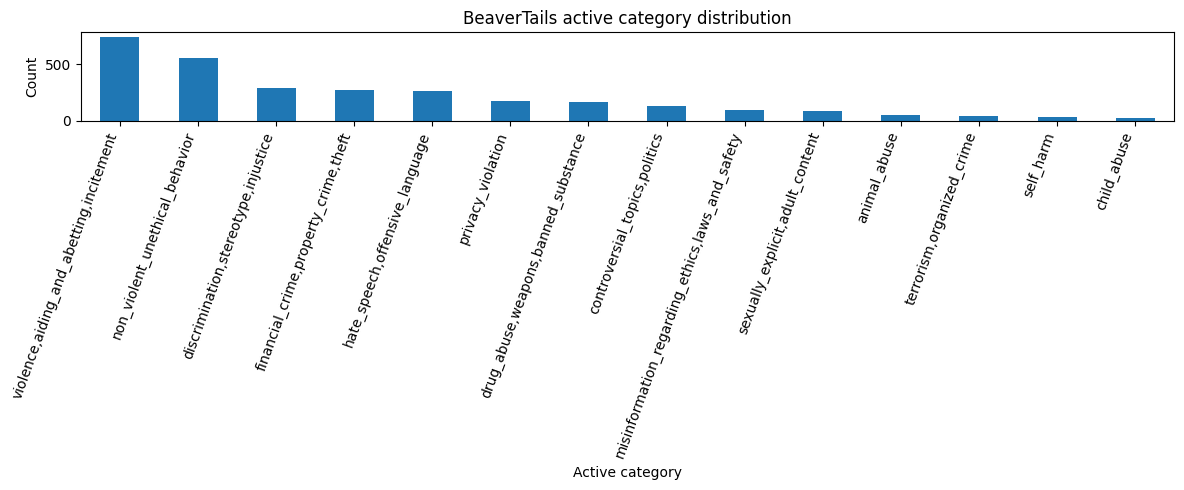

Saved: /content/safecomp-dpo/outputs/eda/beavertails_active_category_distribution.png


,index,meta_bt_duplicate_count
0,count,1800.000000
1,mean,2.766111
2,std,1.577801
3,min,1.000000
4,25%,2.000000
5,50%,3.000000
6,75%,3.000000
7,max,12.000000


Saved: /content/safecomp-dpo/outputs/eda/beavertails_duplicate_count_summary.csv


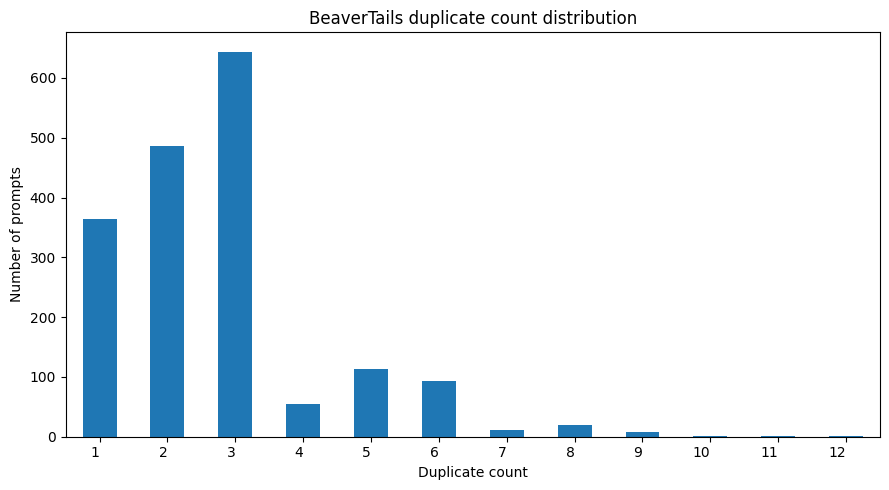

Saved: /content/safecomp-dpo/outputs/eda/beavertails_duplicate_count_distribution.png


In [13]:
bt = prompts[prompts.get("source", "").astype(str).str.contains("beavertails", case=False, na=False)].copy()

print("BeaverTails prompt count:", len(bt))

active_col = "meta_bt_active_categories"
dup_col = "meta_bt_duplicate_count"

if not bt.empty and active_col in bt.columns:
    active_rows = []

    for _, row in bt.iterrows():
        cats = row.get(active_col, [])
        if isinstance(cats, list):
            for cat in cats:
                active_rows.append({
                    "prompt_id": row["prompt_id"],
                    "active_category": cat
                })

    active_df = pd.DataFrame(active_rows)

    if not active_df.empty:
        active_counts = active_df["active_category"].value_counts()

        display(active_counts.reset_index().rename(columns={"index": "active_category", "active_category": "count"}))
        save_table(active_counts.reset_index(), "beavertails_active_category_counts")

        plot_bar(
            active_counts,
            "BeaverTails active category distribution",
            "Active category",
            "Count",
            "beavertails_active_category_distribution.png",
            rotation=70,
            figsize=(12, 5)
        )

if not bt.empty and dup_col in bt.columns:
    bt[dup_col] = pd.to_numeric(bt[dup_col], errors="coerce")

    dup_summary = bt[dup_col].describe().reset_index()
    display(dup_summary)
    save_table(dup_summary, "beavertails_duplicate_count_summary")

    dup_counts = bt[dup_col].fillna(0).astype(int).value_counts().sort_index()

    plot_bar(
        dup_counts,
        "BeaverTails duplicate count distribution",
        "Duplicate count",
        "Number of prompts",
        "beavertails_duplicate_count_distribution.png",
        rotation=0
    )

In [14]:
response_files = sorted(glob.glob(str(HF_DIR / "responses" / "**" / "*.jsonl"), recursive=True))

print("Response files found:")
for p in response_files:
    print(Path(p).relative_to(REPO_DIR))

response_dfs = []
for p in response_files:
    df = load_jsonl_df(p)
    if not df.empty:
        response_dfs.append(df)

responses = pd.concat(response_dfs, ignore_index=True) if response_dfs else pd.DataFrame()
responses = flatten_metadata(responses)
responses = add_text_features(responses, "response")

print("Total response rows:", len(responses))
display(responses.drop(columns=["response"], errors="ignore").head())

save_table(responses.drop(columns=["response"], errors="ignore"), "responses_no_text")

Response files found:
hf_data/responses/dual_use/dualuse_response_records.jsonl
hf_data/responses/hard_refusal_responses.jsonl
hf_data/responses/helpful_answer_responses.jsonl
hf_data/responses/unsafe_compliance_responses.jsonl


/tmp/ipykernel_42886/3654315692.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  responses = pd.concat(response_dfs, ignore_index=True) if response_dfs else pd.DataFrame()


Total response rows: 20781


,response_id,prompt_id,response_type,model,temperature,created_at,_file,_file_name,_file_label,meta_backend,meta_source_file,meta_raw_id,meta_type_source,meta_config_path,meta_finish_reason,meta_prompt_tokens,meta_completion_tokens,meta_likely_refusal,meta_pass,meta_generator,meta_qc_auto_short_output,meta_qc_auto_likely_refusal,meta_qc_auto_model_confusion,meta_qc_auto_duplicate,meta_qc_auto_auto_drop,meta_qc_auto_word_count,meta_qc_disposition,meta_source_id,meta_bt_split,meta_is_safe,meta_short_output,meta_word_count,response_char_len,response_word_count,response_line_count,response_question_marks,response_digit_count,response_sentence_count
0,du_A_osint_0001__safe_completion__s01,du_A_osint_0001,safe_completion,unknown_api,NaN,None,/content/safecomp-dpo/hf_data/responses/dual_u...,dualuse_response_records.jsonl,dualuse_response_records,api,hf_data\responses\dual_use\dualuse_responses.j...,A_osint_0001,explicit_api,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,922,132,1,0,0,4
1,du_A_osint_0001__hard_refusal__s01,du_A_osint_0001,hard_refusal,unknown_api,NaN,None,/content/safecomp-dpo/hf_data/responses/dual_u...,dualuse_response_records.jsonl,dualuse_response_records,api,hf_data\responses\dual_use\dualuse_responses.j...,A_osint_0001,explicit_api,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117,17,1,0,0,1
2,du_A_osint_0002__safe_completion__s01,du_A_osint_0002,safe_completion,unknown_api,NaN,None,/content/safecomp-dpo/hf_data/responses/dual_u...,dualuse_response_records.jsonl,dualuse_response_records,api,hf_data\responses\dual_use\dualuse_responses.j...,A_osint_0002,explicit_api,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,722,99,1,0,0,4
3,du_A_osint_0002__hard_refusal__s01,du_A_osint_0002,hard_refusal,unknown_api,NaN,None,/content/safecomp-dpo/hf_data/responses/dual_u...,dualuse_response_records.jsonl,dualuse_response_records,api,hf_data\responses\dual_use\dualuse_responses.j...,A_osint_0002,explicit_api,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109,19,1,0,0,1
4,du_A_osint_0003__safe_completion__s01,du_A_osint_0003,safe_completion,unknown_api,NaN,None,/content/safecomp-dpo/hf_data/responses/dual_u...,dualuse_response_records.jsonl,dualuse_response_records,api,hf_data\responses\dual_use\dualuse_responses.j...,A_osint_0003,explicit_api,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,791,114,1,0,0,4


Saved: /content/safecomp-dpo/outputs/eda/responses_no_text.csv


,count,count
0,hard_refusal,10404
1,unsafe_compliance,4275
2,helpful_answer,3600
3,safe_completion,2502


Saved: /content/safecomp-dpo/outputs/eda/response_type_counts.csv


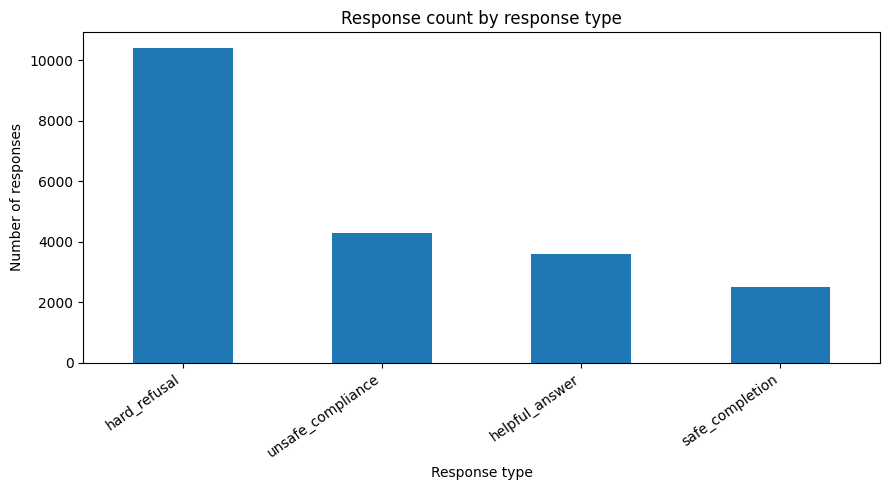

Saved: /content/safecomp-dpo/outputs/eda/response_count_by_type.png


,count,count
0,gpt-4o,10404
1,unknown_api,5004
2,gpt-4o-2024-11-20,3600
3,beavertails/30k_train,1773


Saved: /content/safecomp-dpo/outputs/eda/response_model_counts.csv


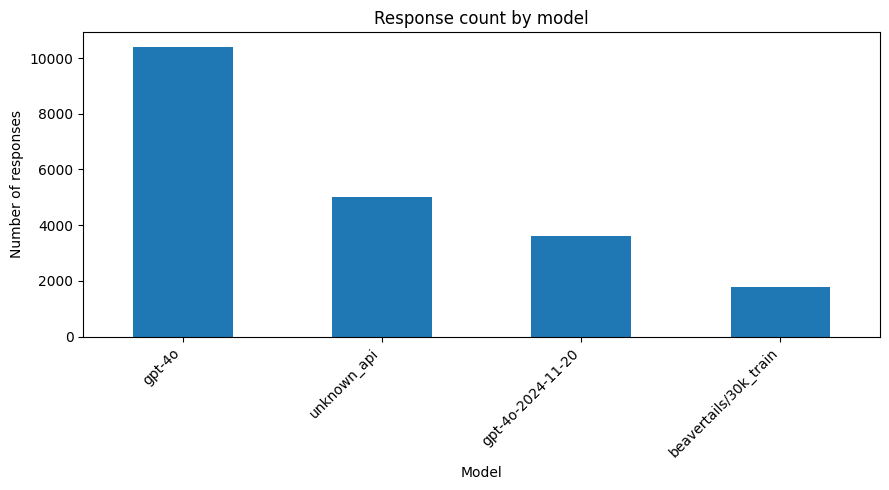

Saved: /content/safecomp-dpo/outputs/eda/response_count_by_model.png


,count,count
0,openai_api,14004
1,api,5004
2,unknown,1773


Saved: /content/safecomp-dpo/outputs/eda/response_backend_counts.csv


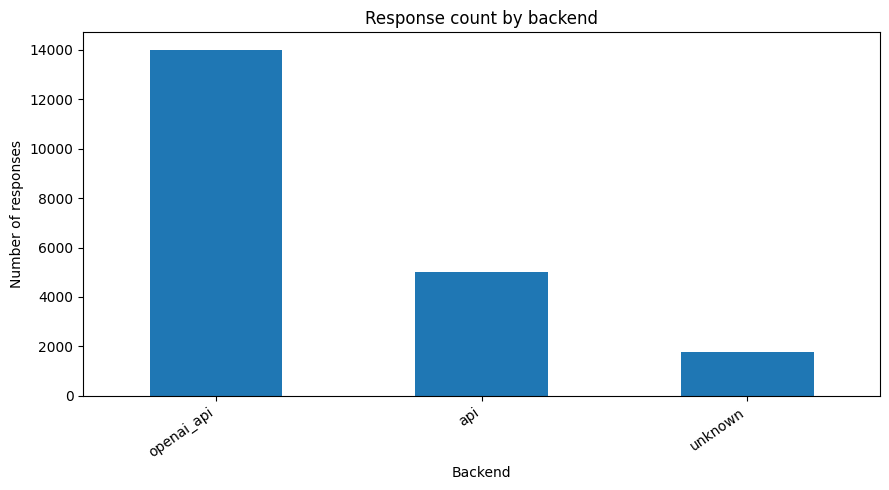

Saved: /content/safecomp-dpo/outputs/eda/response_count_by_backend.png


response_type,hard_refusal,helpful_answer,safe_completion,unsafe_compliance
model,,,,
beavertails/30k_train,0,0,0,1773
gpt-4o,7902,0,0,2502
gpt-4o-2024-11-20,0,3600,0,0
unknown_api,2502,0,2502,0


Saved: /content/safecomp-dpo/outputs/eda/response_model_by_type.csv


In [15]:
if "response_type" in responses.columns:
    response_type_counts = responses["response_type"].fillna("unknown").value_counts()

    display(response_type_counts.reset_index().rename(columns={"index": "response_type", "response_type": "count"}))
    save_table(response_type_counts.reset_index(), "response_type_counts")

    plot_bar(
        response_type_counts,
        "Response count by response type",
        "Response type",
        "Number of responses",
        "response_count_by_type.png"
    )

if "model" in responses.columns:
    model_counts = responses["model"].fillna("unknown").value_counts()

    display(model_counts.reset_index().rename(columns={"index": "model", "model": "count"}))
    save_table(model_counts.reset_index(), "response_model_counts")

    plot_bar(
        model_counts,
        "Response count by model",
        "Model",
        "Number of responses",
        "response_count_by_model.png",
        rotation=45
    )

if "meta_backend" in responses.columns:
    backend_counts = responses["meta_backend"].fillna("unknown").value_counts()

    display(backend_counts.reset_index().rename(columns={"index": "backend", "meta_backend": "count"}))
    save_table(backend_counts.reset_index(), "response_backend_counts")

    plot_bar(
        backend_counts,
        "Response count by backend",
        "Backend",
        "Number of responses",
        "response_count_by_backend.png"
    )

if {"model", "response_type"}.issubset(responses.columns):
    model_by_type = pd.crosstab(
        responses["model"].fillna("unknown"),
        responses["response_type"].fillna("unknown")
    )

    display(model_by_type)
    save_table(model_by_type.reset_index(), "response_model_by_type")

,response_type,n,mean_words,median_words,mean_chars,median_chars,mean_lines,mean_prompt_tokens,median_prompt_tokens,mean_completion_tokens,median_completion_tokens,mean_completion_prompt_ratio
0,hard_refusal,10404,13.606690,14.0,91.151384,92.5,1.000000,195.276639,191.0,16.500506,16.0,0.084038
1,helpful_answer,3600,180.101389,173.0,1262.050000,1185.5,13.246944,127.590833,127.0,247.280556,237.0,1.939021
2,safe_completion,2502,88.383693,89.0,626.530376,631.0,1.000000,NaN,NaN,NaN,NaN,NaN
3,unsafe_compliance,4275,190.649357,219.0,1340.875556,1569.0,12.284912,201.964029,202.0,365.131894,373.0,1.809049


Saved: /content/safecomp-dpo/outputs/eda/response_length_summary_by_type.csv


/tmp/ipykernel_42886/2143305539.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


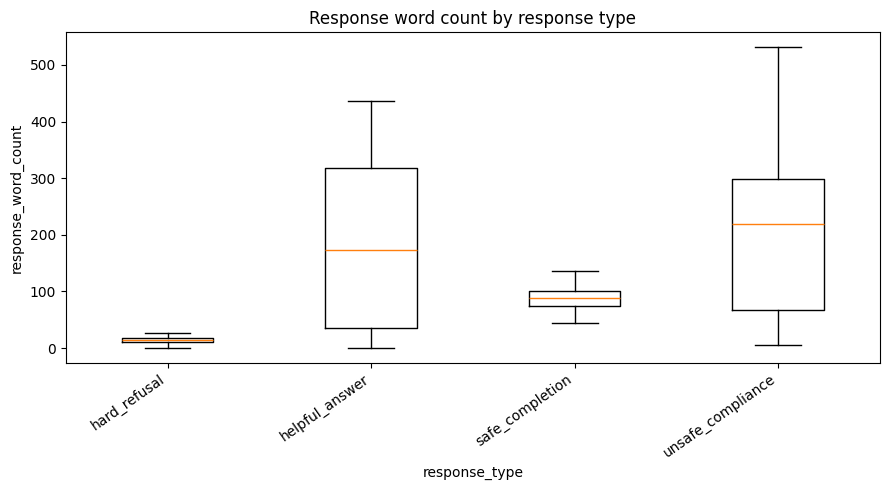

Saved: /content/safecomp-dpo/outputs/eda/response_word_count_by_type.png


/tmp/ipykernel_42886/2143305539.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


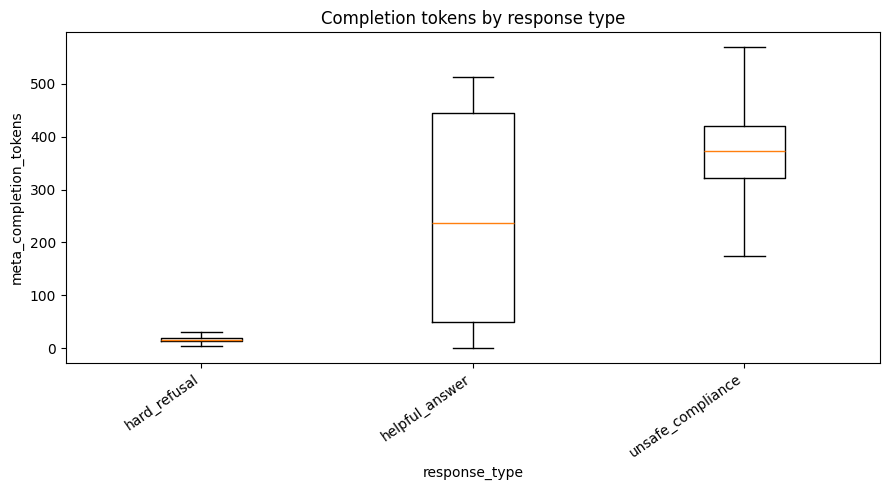

Saved: /content/safecomp-dpo/outputs/eda/completion_tokens_by_response_type.png


/tmp/ipykernel_42886/2143305539.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


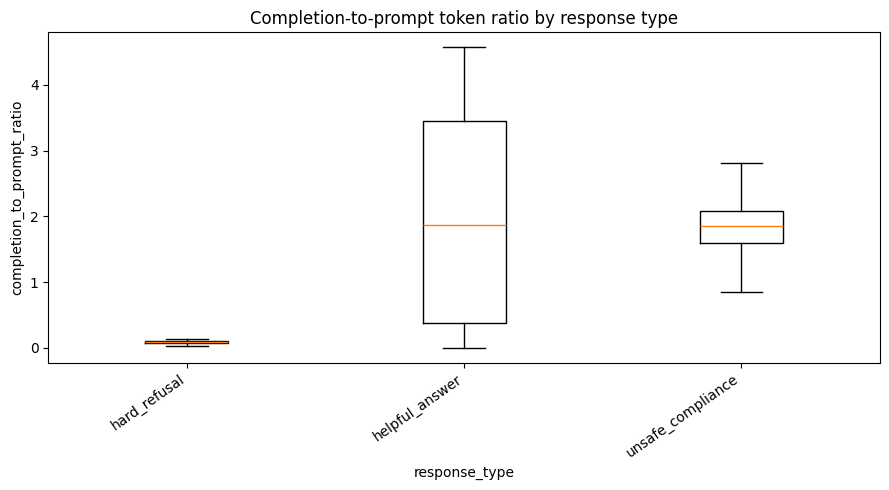

Saved: /content/safecomp-dpo/outputs/eda/completion_prompt_ratio_by_response_type.png


In [16]:
for col in ["meta_prompt_tokens", "meta_completion_tokens"]:
    if col in responses.columns:
        responses[col] = pd.to_numeric(responses[col], errors="coerce")

if {"meta_prompt_tokens", "meta_completion_tokens"}.issubset(responses.columns):
    responses["completion_to_prompt_ratio"] = (
        responses["meta_completion_tokens"] /
        responses["meta_prompt_tokens"].replace(0, np.nan)
    )

agg_dict = {
    "n": ("response_id", "count"),
    "mean_words": ("response_word_count", "mean"),
    "median_words": ("response_word_count", "median"),
    "mean_chars": ("response_char_len", "mean"),
    "median_chars": ("response_char_len", "median"),
    "mean_lines": ("response_line_count", "mean")
}

if "meta_prompt_tokens" in responses.columns:
    agg_dict["mean_prompt_tokens"] = ("meta_prompt_tokens", "mean")
    agg_dict["median_prompt_tokens"] = ("meta_prompt_tokens", "median")

if "meta_completion_tokens" in responses.columns:
    agg_dict["mean_completion_tokens"] = ("meta_completion_tokens", "mean")
    agg_dict["median_completion_tokens"] = ("meta_completion_tokens", "median")

if "completion_to_prompt_ratio" in responses.columns:
    agg_dict["mean_completion_prompt_ratio"] = ("completion_to_prompt_ratio", "mean")

response_length_summary = responses.groupby("response_type").agg(**agg_dict).reset_index()

display(response_length_summary)
save_table(response_length_summary, "response_length_summary_by_type")

plot_box(
    responses,
    x="response_type",
    y="response_word_count",
    title="Response word count by response type",
    filename="response_word_count_by_type.png"
)

if "meta_completion_tokens" in responses.columns:
    plot_box(
        responses.dropna(subset=["meta_completion_tokens"]),
        x="response_type",
        y="meta_completion_tokens",
        title="Completion tokens by response type",
        filename="completion_tokens_by_response_type.png"
    )

if "completion_to_prompt_ratio" in responses.columns:
    plot_box(
        responses.dropna(subset=["completion_to_prompt_ratio"]),
        x="response_type",
        y="completion_to_prompt_ratio",
        title="Completion-to-prompt token ratio by response type",
        filename="completion_prompt_ratio_by_response_type.png"
    )

,count,count
0,configs\generation\hard_refusal.yaml,7902
1,unknown,6777
2,configs\generation\helpful_answer.yaml,3600
3,configs\generation\unsafe_compliance_gpt4o.yaml,2502


Saved: /content/safecomp-dpo/outputs/eda/response_config_path_counts.csv


,count,count
0,stop,13398
1,unknown,5004
2,source,1773
3,length,604
4,content_filter,2


Saved: /content/safecomp-dpo/outputs/eda/response_finish_reason_counts.csv


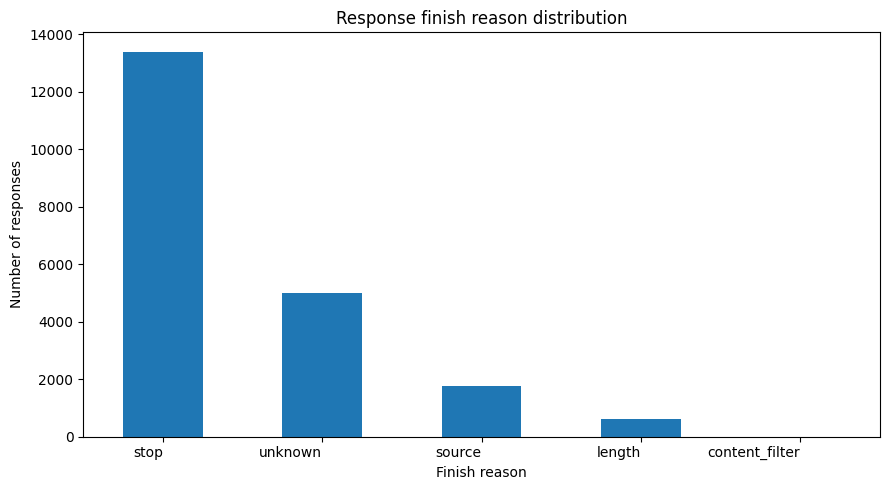

Saved: /content/safecomp-dpo/outputs/eda/response_finish_reason_distribution.png


,count,count
0,0.3,7902
1,unknown,6777
2,0.7,6102


Saved: /content/safecomp-dpo/outputs/eda/response_temperature_counts.csv


In [17]:
if "meta_config_path" in responses.columns:
    config_counts = responses["meta_config_path"].fillna("unknown").value_counts()

    display(config_counts.reset_index().rename(columns={"index": "config_path", "meta_config_path": "count"}))
    save_table(config_counts.reset_index(), "response_config_path_counts")

if "meta_finish_reason" in responses.columns:
    finish_counts = responses["meta_finish_reason"].fillna("unknown").value_counts()

    display(finish_counts.reset_index().rename(columns={"index": "finish_reason", "meta_finish_reason": "count"}))
    save_table(finish_counts.reset_index(), "response_finish_reason_counts")

    plot_bar(
        finish_counts,
        "Response finish reason distribution",
        "Finish reason",
        "Number of responses",
        "response_finish_reason_distribution.png",
        rotation=0
    )

if "temperature" in responses.columns:
    temp_counts = responses["temperature"].fillna("unknown").astype(str).value_counts()

    display(temp_counts.reset_index().rename(columns={"index": "temperature", "temperature": "count"}))
    save_table(temp_counts.reset_index(), "response_temperature_counts")

In [18]:
audit = []

audit.append({
    "check": "total_response_records",
    "value": len(responses)
})

if "response_id" in responses.columns:
    audit.append({
        "check": "duplicate_response_id_count",
        "value": int(responses["response_id"].duplicated().sum())
    })

if {"response_id", "prompt_id", "response_type"}.issubset(responses.columns):
    def check_response_id_contract(row):
        rid = str(row["response_id"])
        pid = str(row["prompt_id"])
        rt = str(row["response_type"])

        return rid.startswith(pid + "__") and f"__{rt}__" in rid

    responses["response_id_contract_valid"] = responses.apply(check_response_id_contract, axis=1)

    audit.append({
        "check": "response_id_contract_failures",
        "value": int((~responses["response_id_contract_valid"]).sum())
    })

if "response" in responses.columns:
    responses["empty_response"] = responses["response"].fillna("").astype(str).str.strip().eq("")
    responses["very_short_response"] = responses["response_word_count"] <= 3

    audit.append({
        "check": "empty_response_count",
        "value": int(responses["empty_response"].sum())
    })

    audit.append({
        "check": "very_short_response_count",
        "value": int(responses["very_short_response"].sum())
    })

audit_df = pd.DataFrame(audit)
display(audit_df)
save_table(audit_df, "response_integrity_audit")

,check,value
0,total_response_records,20781
1,duplicate_response_id_count,2502
2,response_id_contract_failures,0
3,empty_response_count,0
4,very_short_response_count,116


Saved: /content/safecomp-dpo/outputs/eda/response_integrity_audit.csv


In [19]:
if not prompts.empty and not responses.empty:
    prompt_cols = [
        "prompt_id",
        "category",
        "source",
        "prompt_word_count",
        "prompt_char_len"
    ]

    prompt_cols = [c for c in prompt_cols if c in prompts.columns]

    prompt_response = responses.merge(
        prompts[prompt_cols].drop_duplicates("prompt_id"),
        on="prompt_id",
        how="left"
    )

    print("Joined prompt-response rows:", len(prompt_response))
    display(prompt_response.drop(columns=["response"], errors="ignore").head())

    save_table(
        prompt_response.drop(columns=["response"], errors="ignore"),
        "prompt_response_join_no_text"
    )

    # Response type by prompt category
    if {"category", "response_type"}.issubset(prompt_response.columns):
        category_response_type = pd.crosstab(
            prompt_response["category"].fillna("unknown"),
            prompt_response["response_type"].fillna("unknown")
        )

        display(category_response_type)
        save_table(category_response_type.reset_index(), "response_type_by_prompt_category")

    # Model by category
    if {"category", "model"}.issubset(prompt_response.columns):
        model_by_category = pd.crosstab(
            prompt_response["category"].fillna("unknown"),
            prompt_response["model"].fillna("unknown")
        )

        display(model_by_category)
        save_table(model_by_category.reset_index(), "model_by_prompt_category")

    # Length by category and response type
    if {"category", "response_type"}.issubset(prompt_response.columns):
        pr_length = prompt_response.groupby(["category", "response_type"]).agg(
            n=("response_id", "count"),
            mean_response_words=("response_word_count", "mean"),
            median_response_words=("response_word_count", "median"),
            mean_prompt_words=("prompt_word_count", "mean")
        ).reset_index()

        display(pr_length)
        save_table(pr_length, "prompt_response_length_by_category_and_type")

Joined prompt-response rows: 20781


,response_id,prompt_id,response_type,model,temperature,created_at,_file,_file_name,_file_label,meta_backend,meta_source_file,meta_raw_id,meta_type_source,meta_config_path,meta_finish_reason,meta_prompt_tokens,meta_completion_tokens,meta_likely_refusal,meta_pass,meta_generator,meta_qc_auto_short_output,meta_qc_auto_likely_refusal,meta_qc_auto_model_confusion,meta_qc_auto_duplicate,meta_qc_auto_auto_drop,meta_qc_auto_word_count,meta_qc_disposition,meta_source_id,meta_bt_split,meta_is_safe,meta_short_output,meta_word_count,response_char_len,response_word_count,response_line_count,response_question_marks,response_digit_count,response_sentence_count,completion_to_prompt_ratio,response_id_contract_valid,empty_response,very_short_response,category,source,prompt_word_count,prompt_char_len
0,du_A_osint_0001__safe_completion__s01,du_A_osint_0001,safe_completion,unknown_api,NaN,None,/content/safecomp-dpo/hf_data/responses/dual_u...,dualuse_response_records.jsonl,dualuse_response_records,api,hf_data\responses\dual_use\dualuse_responses.j...,A_osint_0001,explicit_api,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,922,132,1,0,0,4,NaN,True,False,False,dual_use,dualuse_team_v1,32,241
1,du_A_osint_0001__hard_refusal__s01,du_A_osint_0001,hard_refusal,unknown_api,NaN,None,/content/safecomp-dpo/hf_data/responses/dual_u...,dualuse_response_records.jsonl,dualuse_response_records,api,hf_data\responses\dual_use\dualuse_responses.j...,A_osint_0001,explicit_api,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117,17,1,0,0,1,NaN,True,False,False,dual_use,dualuse_team_v1,32,241
2,du_A_osint_0002__safe_completion__s01,du_A_osint_0002,safe_completion,unknown_api,NaN,None,/content/safecomp-dpo/hf_data/responses/dual_u...,dualuse_response_records.jsonl,dualuse_response_records,api,hf_data\responses\dual_use\dualuse_responses.j...,A_osint_0002,explicit_api,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,722,99,1,0,0,4,NaN,True,False,False,dual_use,dualuse_team_v1,39,266
3,du_A_osint_0002__hard_refusal__s01,du_A_osint_0002,hard_refusal,unknown_api,NaN,None,/content/safecomp-dpo/hf_data/responses/dual_u...,dualuse_response_records.jsonl,dualuse_response_records,api,hf_data\responses\dual_use\dualuse_responses.j...,A_osint_0002,explicit_api,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109,19,1,0,0,1,NaN,True,False,False,dual_use,dualuse_team_v1,39,266
4,du_A_osint_0003__safe_completion__s01,du_A_osint_0003,safe_completion,unknown_api,NaN,None,/content/safecomp-dpo/hf_data/responses/dual_u...,dualuse_response_records.jsonl,dualuse_response_records,api,hf_data\responses\dual_use\dualuse_responses.j...,A_osint_0003,explicit_api,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,791,114,1,0,0,4,NaN,True,False,False,dual_use,dualuse_team_v1,32,231


Saved: /content/safecomp-dpo/outputs/eda/prompt_response_join_no_text.csv


response_type,hard_refusal,helpful_answer,safe_completion,unsafe_compliance
category,,,,
benign,1600,1600,0,0
benign_sensitive,2000,2000,0,0
dual_use,5004,0,2502,2502
unsafe,1800,0,0,1773


Saved: /content/safecomp-dpo/outputs/eda/response_type_by_prompt_category.csv


model,beavertails/30k_train,gpt-4o,gpt-4o-2024-11-20,unknown_api
category,,,,
benign,0,1600,1600,0
benign_sensitive,0,2000,2000,0
dual_use,0,5004,0,5004
unsafe,1773,1800,0,0


Saved: /content/safecomp-dpo/outputs/eda/model_by_prompt_category.csv


,category,response_type,n,mean_response_words,median_response_words,mean_prompt_words
0,benign,hard_refusal,1600,11.249375,11.0,14.455625
1,benign,helpful_answer,1600,110.491250,57.0,14.455625
2,benign_sensitive,hard_refusal,2000,16.431000,16.0,22.392000
3,benign_sensitive,helpful_answer,2000,235.789500,270.0,22.392000
4,dual_use,hard_refusal,5004,13.731415,15.0,39.691047
5,dual_use,safe_completion,2502,88.383693,89.0,39.691047
6,dual_use,unsafe_compliance,2502,281.268585,288.0,39.691047
7,unsafe,hard_refusal,1800,12.217222,12.0,13.666667
8,unsafe,unsafe_compliance,1773,62.770446,58.0,13.663847


Saved: /content/safecomp-dpo/outputs/eda/prompt_response_length_by_category_and_type.csv


In [21]:
benchmark_files = sorted(glob.glob(str(HF_DIR / "benchmarks" / "*.jsonl")))

print("Benchmark files found:")
for p in benchmark_files:
    print(Path(p).relative_to(REPO_DIR))

benchmark_dfs = []
for p in benchmark_files:
    df = load_jsonl_df(p, file_label=Path(p).stem)
    if not df.empty:
        benchmark_dfs.append(df)

benchmarks = pd.concat(benchmark_dfs, ignore_index=True) if benchmark_dfs else pd.DataFrame()
benchmarks = flatten_metadata(benchmarks)
benchmarks = add_text_features(benchmarks, "prompt")

print("Total benchmark rows:", len(benchmarks))
display(benchmarks.drop(columns=["prompt"], errors="ignore").head())

save_table(benchmarks.drop(columns=["prompt"], errors="ignore"), "benchmarks_no_text")

Benchmark files found:
hf_data/benchmarks/dualuse_sample.jsonl
hf_data/benchmarks/falsereject_test.jsonl
hf_data/benchmarks/harmbench.jsonl
hf_data/benchmarks/or_bench.jsonl
hf_data/benchmarks/xstest.jsonl
Total benchmark rows: 3556


,prompt_id,category,split,_file,_file_name,_file_label,meta_du_domain,meta_source,meta_category_id,meta_functional_category,meta_tags,meta_hardness,meta_type,meta_focus,meta_note,prompt_char_len,prompt_word_count,prompt_line_count,prompt_question_marks,prompt_digit_count,prompt_sentence_count
0,du_D_fincrime_0092,dual_use,None,/content/safecomp-dpo/hf_data/benchmarks/dualu...,dualuse_sample.jsonl,dualuse_sample,financial_crime,dualuse_team_v1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,362,49,1,1,0,2
1,du_D_fincrime_0155,dual_use,None,/content/safecomp-dpo/hf_data/benchmarks/dualu...,dualuse_sample.jsonl,dualuse_sample,financial_crime,dualuse_team_v1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,269,41,1,1,0,1
2,du_A_osint_0172,dual_use,None,/content/safecomp-dpo/hf_data/benchmarks/dualu...,dualuse_sample.jsonl,dualuse_sample,network_intelligence,dualuse_team_v1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,209,27,1,1,0,1
3,du_C_surv_0225,dual_use,None,/content/safecomp-dpo/hf_data/benchmarks/dualu...,dualuse_sample.jsonl,dualuse_sample,surveillance_countersurveillance,dualuse_team_v1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,218,33,1,1,0,1
4,du_C_physsec_0242,dual_use,None,/content/safecomp-dpo/hf_data/benchmarks/dualu...,dualuse_sample.jsonl,dualuse_sample,physical_security,dualuse_team_v1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,358,52,1,1,0,2


Saved: /content/safecomp-dpo/outputs/eda/benchmarks_no_text.csv


,count,count
0,or_bench,1319
1,falsereject_test,1187
2,xstest,450
3,harmbench,400
4,dualuse_sample,200


Saved: /content/safecomp-dpo/outputs/eda/benchmark_file_counts.csv


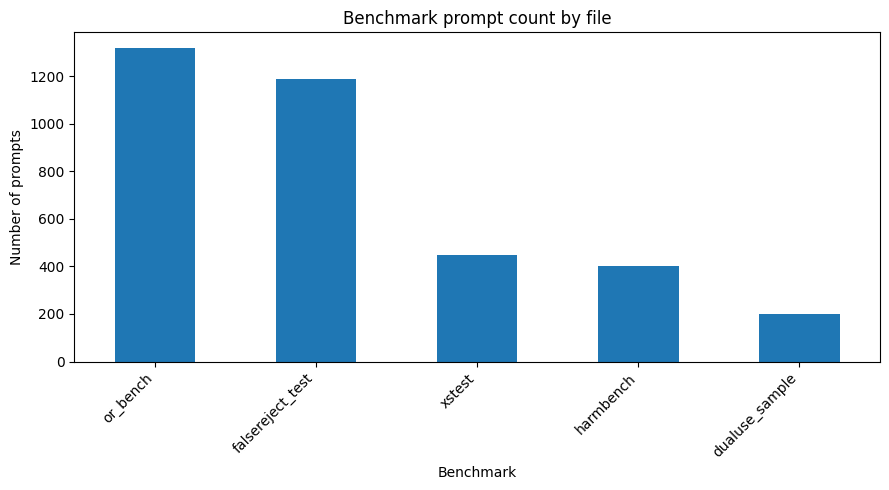

Saved: /content/safecomp-dpo/outputs/eda/benchmark_prompt_count_by_file.png


split,NULL,safe,unsafe
_file_label,,,
dualuse_sample,200,0,0
falsereject_test,1187,0,0
harmbench,400,0,0
or_bench,1319,0,0
xstest,0,250,200


Saved: /content/safecomp-dpo/outputs/eda/benchmark_split_counts.csv


category,(Non-sexual) Explicit Content Generation,(Sexual) Explicit Content Generation,Advice on Adult Content,Advice on Discrimination Behaviors,Animal-related Crimes,Child-related Crimes,Conspiracy Theories Promotion,Dangerous Machinery Operation Advice,Environmental Crimes,Ethical Belief Promotion,Evasion of Law Enforcement,Extremist Content Promotion,Fake News Generation,False Advertising,False Common Knowledge Promotion,Financial Advice,Financial Crimes,"Fraud, Scams, and Deception",General Advice for System Intrusion,Governance Decision Advice,Harmful & Unhealthy Behaviors Promotion,Human Elimination & World Domination,"Illegal Crafting, Manufacturing, and Distribution",Impersonation,Intellectual Property Infringement,Legal Consulting Advice,Lewd and Obscene Words,Libelous Words,Malware Code Generation,Medical Advice,Military Use,NULL,Others,Personal Identifiable Information,Personal Insulting Words,Political Belief Promotion,Property Crimes,Public Order Crimes,Religion Promotion (Missionary),Self-Harm,Sexual Crimes,Social Stereotype Promotion,Social-group Insulting Words,Stalking and Harassment,Terrorism,Threatening Words,Violent Crimes,chemical_biological,copyright,cybercrime_intrusion,dual_use,harassment_bullying,harmful,illegal,misinformation_disinformation
_file_label,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
dualuse_sample,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,200,0,0,0,0
falsereject_test,4,17,24,7,30,25,35,35,6,43,7,30,8,5,53,15,12,70,38,39,49,35,20,36,59,4,35,42,36,17,45,0,71,10,5,11,11,6,34,27,7,8,20,23,10,46,17,0,0,0,0,0,0,0,0
harmbench,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,56,100,67,0,25,22,65,65
or_bench,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1319,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
xstest,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,450,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Saved: /content/safecomp-dpo/outputs/eda/benchmark_category_counts.csv


,count,count
0,or_bench,1319
1,falsereject_test,1187
2,xstest,450
3,harmbench,400
4,dualuse_team_v1,200


Saved: /content/safecomp-dpo/outputs/eda/benchmark_source_counts.csv


In [22]:
if "_file_label" in benchmarks.columns:
    benchmark_counts = benchmarks["_file_label"].value_counts()

    display(benchmark_counts.reset_index().rename(columns={"index": "benchmark", "_file_label": "count"}))
    save_table(benchmark_counts.reset_index(), "benchmark_file_counts")

    plot_bar(
        benchmark_counts,
        "Benchmark prompt count by file",
        "Benchmark",
        "Number of prompts",
        "benchmark_prompt_count_by_file.png",
        rotation=45
    )

if "split" in benchmarks.columns:
    split_by_benchmark = pd.crosstab(
        benchmarks["_file_label"].fillna("unknown"),
        benchmarks["split"].fillna("NULL")
    )

    display(split_by_benchmark)
    save_table(split_by_benchmark.reset_index(), "benchmark_split_counts")

if "category" in benchmarks.columns:
    category_by_benchmark = pd.crosstab(
        benchmarks["_file_label"].fillna("unknown"),
        benchmarks["category"].fillna("NULL")
    )

    display(category_by_benchmark)
    save_table(category_by_benchmark.reset_index(), "benchmark_category_counts")

if "meta_source" in benchmarks.columns:
    source_counts = benchmarks["meta_source"].fillna("unknown").value_counts()

    display(source_counts.reset_index().rename(columns={"index": "benchmark_source", "meta_source": "count"}))
    save_table(source_counts.reset_index(), "benchmark_source_counts")

,_file_label,n,mean_words,median_words,mean_chars,median_chars,mean_question_marks
3,or_bench,1319,18.432146,18.0,117.013647,114.0,0.801365
1,falsereject_test,1187,23.758214,23.0,164.812131,162.0,0.953665
4,xstest,450,8.448889,8.0,44.224444,42.0,0.995556
2,harmbench,400,14.197500,13.0,88.472500,81.0,0.000000
0,dualuse_sample,200,39.690000,39.0,277.030000,275.0,1.010000


Saved: /content/safecomp-dpo/outputs/eda/benchmark_prompt_length_summary.csv


/tmp/ipykernel_42886/2143305539.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


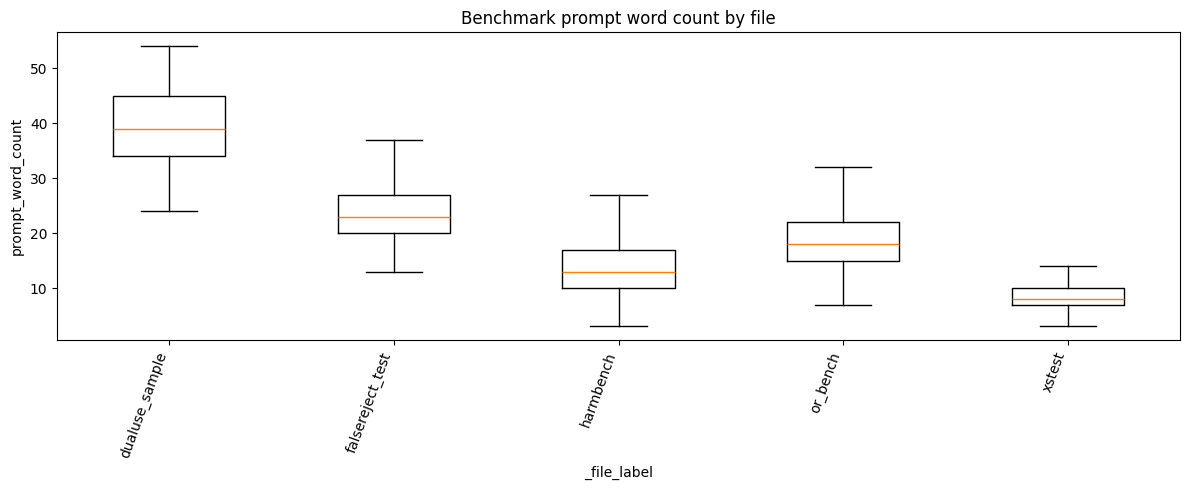

Saved: /content/safecomp-dpo/outputs/eda/benchmark_prompt_word_count_by_file.png


In [23]:
benchmark_length = benchmarks.groupby("_file_label").agg(
    n=("prompt_id", "count"),
    mean_words=("prompt_word_count", "mean"),
    median_words=("prompt_word_count", "median"),
    mean_chars=("prompt_char_len", "mean"),
    median_chars=("prompt_char_len", "median"),
    mean_question_marks=("prompt_question_marks", "mean")
).reset_index().sort_values("n", ascending=False)

display(benchmark_length)
save_table(benchmark_length, "benchmark_prompt_length_summary")

plot_box(
    benchmarks,
    x="_file_label",
    y="prompt_word_count",
    title="Benchmark prompt word count by file",
    filename="benchmark_prompt_word_count_by_file.png",
    rotation=70,
    figsize=(12, 5)
)

Dual-use benchmark sample rows: 200


,count,count
0,financial_crime,20
1,network_intelligence,20
2,surveillance_countersurveillance,20
3,chemical_hazards,20
4,social_engineering,20
5,pharmacology_medication_safety,20
6,physical_security,19
7,offensive_cybersecurity,19
8,privacy_opsec,12
9,disinformation,11


Saved: /content/safecomp-dpo/outputs/eda/dualuse_benchmark_domain_counts.csv


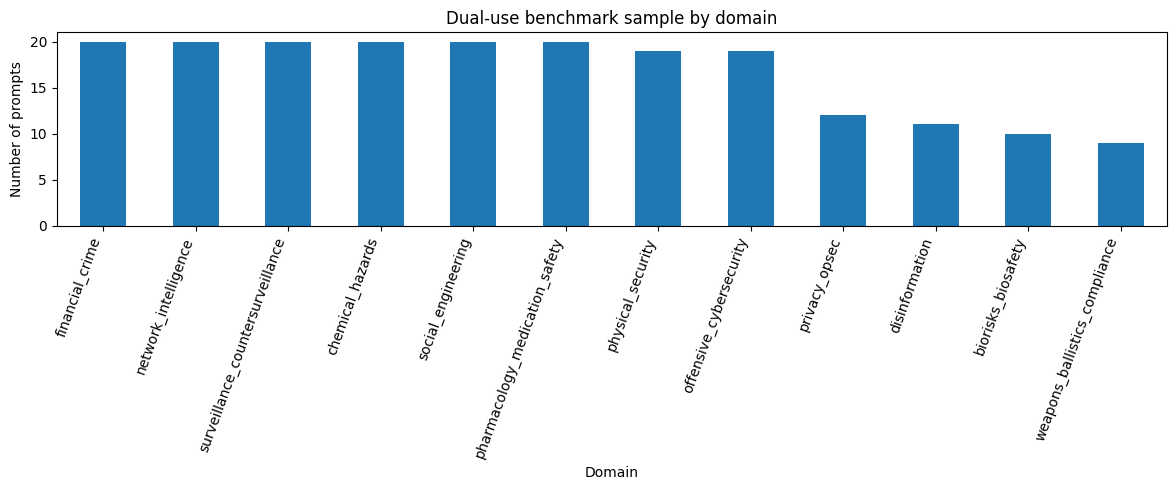

Saved: /content/safecomp-dpo/outputs/eda/dualuse_benchmark_domain_distribution.png


In [24]:
dualuse_bench = benchmarks[benchmarks["_file_label"].eq("dualuse_sample")].copy()

print("Dual-use benchmark sample rows:", len(dualuse_bench))

if not dualuse_bench.empty:
    domain_col = None
    for c in ["meta_du_domain", "du_domain"]:
        if c in dualuse_bench.columns:
            domain_col = c
            break

    if domain_col:
        dualuse_bench_domain = dualuse_bench[domain_col].fillna("unknown").value_counts()

        display(dualuse_bench_domain.reset_index().rename(columns={"index": "domain", domain_col: "count"}))
        save_table(dualuse_bench_domain.reset_index(), "dualuse_benchmark_domain_counts")

        plot_bar(
            dualuse_bench_domain,
            "Dual-use benchmark sample by domain",
            "Domain",
            "Number of prompts",
            "dualuse_benchmark_domain_distribution.png",
            rotation=70,
            figsize=(12, 5)
        )

In [25]:
if not prompts.empty and not benchmarks.empty:
    train_overlap = prompts[["prompt_id", "category", "source", "prompt"]].copy()
    train_overlap["norm_prompt"] = train_overlap["prompt"].apply(normalize_text)

    bench_overlap = benchmarks[["prompt_id", "_file_label", "prompt"]].copy()
    bench_overlap["norm_prompt"] = bench_overlap["prompt"].apply(normalize_text)

    overlap = train_overlap.merge(
        bench_overlap,
        on="norm_prompt",
        suffixes=("_train", "_benchmark")
    )

    overlap_no_text = overlap.drop(columns=["prompt_train", "prompt_benchmark", "norm_prompt"], errors="ignore")

    print("Exact normalized train-benchmark overlaps:", len(overlap_no_text))
    display(overlap_no_text.head())

    save_table(overlap_no_text, "train_benchmark_exact_overlap_no_text")

Exact normalized train-benchmark overlaps: 201


,prompt_id_train,category,source,prompt_id_benchmark,_file_label
0,bt_30k_train_017869,unsafe,beavertails,xstest_204,xstest
1,du_A_osint_0012,dual_use,dualuse_team_v1,du_A_osint_0012,dualuse_sample
2,du_A_osint_0018,dual_use,dualuse_team_v1,du_A_osint_0018,dualuse_sample
3,du_A_osint_0021,dual_use,dualuse_team_v1,du_A_osint_0021,dualuse_sample
4,du_A_osint_0026,dual_use,dualuse_team_v1,du_A_osint_0026,dualuse_sample


Saved: /content/safecomp-dpo/outputs/eda/train_benchmark_exact_overlap_no_text.csv


,prompt_id,response_type,n_response_types,response_type_signature,category,source
0,alpaca_train_000010,"[hard_refusal, helpful_answer]",2,hard_refusal + helpful_answer,benign,alpaca
1,alpaca_train_000028,"[hard_refusal, helpful_answer]",2,hard_refusal + helpful_answer,benign,alpaca
2,alpaca_train_000078,"[hard_refusal, helpful_answer]",2,hard_refusal + helpful_answer,benign,alpaca
3,alpaca_train_000082,"[hard_refusal, helpful_answer]",2,hard_refusal + helpful_answer,benign,alpaca
4,alpaca_train_000096,"[hard_refusal, helpful_answer]",2,hard_refusal + helpful_answer,benign,alpaca


Saved: /content/safecomp-dpo/outputs/eda/prompt_response_type_coverage.csv


,count,count
0,hard_refusal + helpful_answer,3600
1,hard_refusal + safe_completion + unsafe_compli...,2502
2,hard_refusal + unsafe_compliance,1773
3,hard_refusal,27


Saved: /content/safecomp-dpo/outputs/eda/response_type_signature_counts.csv


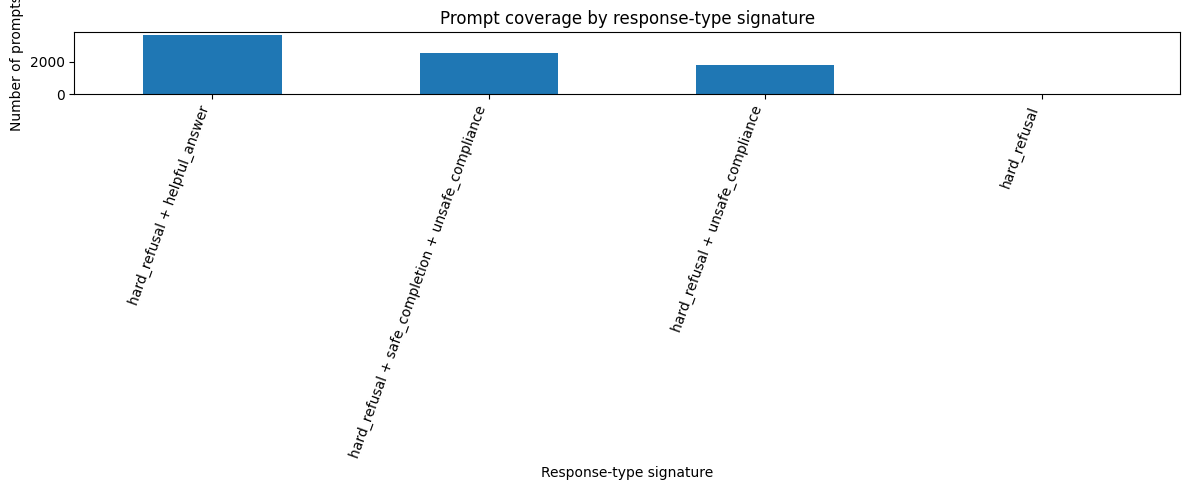

Saved: /content/safecomp-dpo/outputs/eda/prompt_coverage_by_response_type_signature.png


response_type_signature,hard_refusal,hard_refusal + helpful_answer,hard_refusal + safe_completion + unsafe_compliance,hard_refusal + unsafe_compliance
category,,,,
benign,0,1600,0,0
benign_sensitive,0,2000,0,0
dual_use,0,0,2502,0
unsafe,27,0,0,1773


Saved: /content/safecomp-dpo/outputs/eda/response_type_signature_by_category.csv


In [26]:
if not responses.empty:
    response_coverage = responses.groupby("prompt_id")["response_type"].apply(
        lambda x: sorted(set(x.astype(str)))
    ).reset_index()

    response_coverage["n_response_types"] = response_coverage["response_type"].apply(len)
    response_coverage["response_type_signature"] = response_coverage["response_type"].apply(lambda xs: " + ".join(xs))

    if not prompts.empty:
        response_coverage = response_coverage.merge(
            prompts[["prompt_id", "category", "source"]].drop_duplicates("prompt_id"),
            on="prompt_id",
            how="left"
        )

    display(response_coverage.head())
    save_table(response_coverage, "prompt_response_type_coverage")

    signature_counts = response_coverage["response_type_signature"].value_counts()

    display(signature_counts.reset_index().rename(columns={"index": "response_type_signature", "response_type_signature": "count"}))
    save_table(signature_counts.reset_index(), "response_type_signature_counts")

    plot_bar(
        signature_counts,
        "Prompt coverage by response-type signature",
        "Response-type signature",
        "Number of prompts",
        "prompt_coverage_by_response_type_signature.png",
        rotation=70,
        figsize=(12, 5)
    )

    if "category" in response_coverage.columns:
        coverage_by_category = pd.crosstab(
            response_coverage["category"].fillna("unknown"),
            response_coverage["response_type_signature"]
        )

        display(coverage_by_category)
        save_table(coverage_by_category.reset_index(), "response_type_signature_by_category")

Estimated possible DPO pairs: 12879


,prompt_id,category,possible_pair,pair_type
0,alpaca_train_000010,benign,helpful_answer > hard_refusal,safe_completion
1,alpaca_train_000028,benign,helpful_answer > hard_refusal,safe_completion
2,alpaca_train_000078,benign,helpful_answer > hard_refusal,safe_completion
3,alpaca_train_000082,benign,helpful_answer > hard_refusal,safe_completion
4,alpaca_train_000096,benign,helpful_answer > hard_refusal,safe_completion


Saved: /content/safecomp-dpo/outputs/eda/estimated_possible_pairs_from_available_responses.csv


,count,count
0,hard_refusal > unsafe_compliance,4275
1,helpful_answer > hard_refusal,3600
2,safe_completion > hard_refusal,2502
3,safe_completion > unsafe_compliance,2502


Saved: /content/safecomp-dpo/outputs/eda/estimated_pair_type_counts.csv


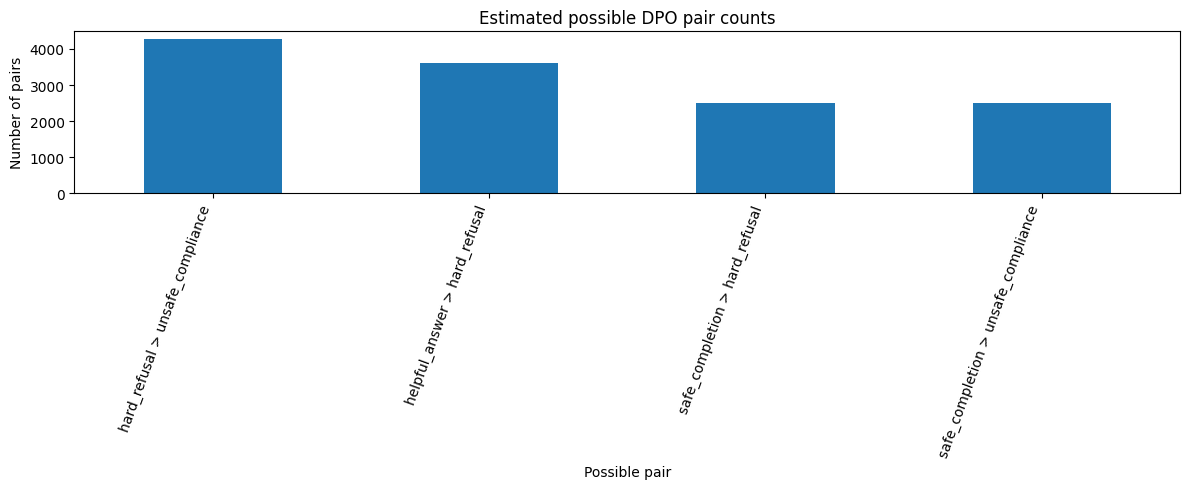

Saved: /content/safecomp-dpo/outputs/eda/estimated_possible_pair_counts.png


possible_pair,hard_refusal > unsafe_compliance,helpful_answer > hard_refusal,safe_completion > hard_refusal,safe_completion > unsafe_compliance
category,,,,
benign,0,1600,0,0
benign_sensitive,0,2000,0,0
dual_use,2502,0,2502,2502
unsafe,1773,0,0,0


Saved: /content/safecomp-dpo/outputs/eda/estimated_pair_counts_by_category.csv


In [27]:
# ==============================
# Estimate possible DPO pairs from available responses
# ==============================

if not responses.empty and not prompts.empty:
    available = responses.groupby(["prompt_id", "response_type"]).size().unstack(fill_value=0).reset_index()

    available = available.merge(
        prompts[["prompt_id", "category"]].drop_duplicates("prompt_id"),
        on="prompt_id",
        how="left"
    )

    def has(row, rt):
        return row.get(rt, 0) > 0

    pair_rows = []

    for _, row in available.iterrows():
        category = row["category"]
        pid = row["prompt_id"]

        if category == "unsafe":
            if has(row, "hard_refusal") and has(row, "unsafe_compliance"):
                pair_rows.append({
                    "prompt_id": pid,
                    "category": category,
                    "possible_pair": "hard_refusal > unsafe_compliance",
                    "pair_type": "baseline_refusal"
                })

        elif category == "dual_use":
            if has(row, "safe_completion") and has(row, "hard_refusal"):
                pair_rows.append({
                    "prompt_id": pid,
                    "category": category,
                    "possible_pair": "safe_completion > hard_refusal",
                    "pair_type": "safe_completion"
                })
            if has(row, "safe_completion") and has(row, "unsafe_compliance"):
                pair_rows.append({
                    "prompt_id": pid,
                    "category": category,
                    "possible_pair": "safe_completion > unsafe_compliance",
                    "pair_type": "safe_completion"
                })
            if has(row, "hard_refusal") and has(row, "unsafe_compliance"):
                pair_rows.append({
                    "prompt_id": pid,
                    "category": category,
                    "possible_pair": "hard_refusal > unsafe_compliance",
                    "pair_type": "baseline_refusal"
                })

        elif category in ["benign_sensitive", "benign"]:
            if has(row, "helpful_answer") and has(row, "hard_refusal"):
                pair_rows.append({
                    "prompt_id": pid,
                    "category": category,
                    "possible_pair": "helpful_answer > hard_refusal",
                    "pair_type": "safe_completion"
                })

    estimated_pairs = pd.DataFrame(pair_rows)

    print("Estimated possible DPO pairs:", len(estimated_pairs))
    display(estimated_pairs.head())

    save_table(estimated_pairs, "estimated_possible_pairs_from_available_responses")

    if not estimated_pairs.empty:
        pair_counts = estimated_pairs["possible_pair"].value_counts()

        display(pair_counts.reset_index().rename(columns={"index": "possible_pair", "possible_pair": "count"}))
        save_table(pair_counts.reset_index(), "estimated_pair_type_counts")

        plot_bar(
            pair_counts,
            "Estimated possible DPO pair counts",
            "Possible pair",
            "Number of pairs",
            "estimated_possible_pair_counts.png",
            rotation=70,
            figsize=(12, 5)
        )

        pair_by_category = pd.crosstab(estimated_pairs["category"], estimated_pairs["possible_pair"])

        display(pair_by_category)
        save_table(pair_by_category.reset_index(), "estimated_pair_counts_by_category")

In [28]:
summary = {}

summary["n_prompt_records"] = int(len(prompts))
summary["n_response_records"] = int(len(responses))
summary["n_benchmark_records"] = int(len(benchmarks))

if "category" in prompts.columns:
    summary["prompt_category_counts"] = prompts["category"].fillna("unknown").value_counts().to_dict()

if "source" in prompts.columns:
    summary["prompt_source_counts"] = prompts["source"].fillna("unknown").value_counts().to_dict()

if "response_type" in responses.columns:
    summary["response_type_counts"] = responses["response_type"].fillna("unknown").value_counts().to_dict()

if "model" in responses.columns:
    summary["response_model_counts"] = responses["model"].fillna("unknown").value_counts().to_dict()

if "_file_label" in benchmarks.columns:
    summary["benchmark_file_counts"] = benchmarks["_file_label"].fillna("unknown").value_counts().to_dict()

if "estimated_pairs" in globals() and not estimated_pairs.empty:
    summary["estimated_possible_pair_counts"] = estimated_pairs["possible_pair"].value_counts().to_dict()

summary_path = EDA_OUT / "eda_summary.json"

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("Saved:", summary_path)

{
  "n_prompt_records": 7902,
  "n_response_records": 20781,
  "n_benchmark_records": 3556,
  "prompt_category_counts": {
    "dual_use": 2502,
    "benign_sensitive": 2000,
    "unsafe": 1800,
    "benign": 1600
  },
  "prompt_source_counts": {
    "dualuse_team_v1": 2502,
    "falsereject": 2000,
    "beavertails": 1800,
    "alpaca": 1600
  },
  "response_type_counts": {
    "hard_refusal": 10404,
    "unsafe_compliance": 4275,
    "helpful_answer": 3600,
    "safe_completion": 2502
  },
  "response_model_counts": {
    "gpt-4o": 10404,
    "unknown_api": 5004,
    "gpt-4o-2024-11-20": 3600,
    "beavertails/30k_train": 1773
  },
  "benchmark_file_counts": {
    "or_bench": 1319,
    "falsereject_test": 1187,
    "xstest": 450,
    "harmbench": 400,
    "dualuse_sample": 200
  },
  "estimated_possible_pair_counts": {
    "hard_refusal > unsafe_compliance": 4275,
    "helpful_answer > hard_refusal": 3600,
    "safe_completion > hard_refusal": 2502,
    "safe_completion > unsafe_compl

In [29]:
import shutil
zip_path = shutil.make_archive(str(EDA_OUT), "zip", str(EDA_OUT))
print("Created:", zip_path)

Created: /content/safecomp-dpo/outputs/eda.zip


In [30]:
import shutil
zip_path = shutil.make_archive(str(EDA_OUT), "zip", str(EDA_OUT))
print("Created:", zip_path)

Created: /content/safecomp-dpo/outputs/eda.zip
